# Homework 2 Explorer

This notebook reproduces the Python calculations and feasible-region plots used in `HW2_solution.md`. The implementation lives in the `.py` files in this folder; the notebook keeps the presentation interactive.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from exercise28 import get_bases_by_vertex, get_basic_feasible_solutions
from exercise29 import solve_exercise_23a, solve_exercise_23b
from exercise211 import get_proof_summary, objective_improvement
from exercise34 import solve_exercise_34
from exercise35 import solve_exercise_35

## Exercise 2.8

The inequalities imply $0 \leq x_1 \leq 3$ and $x_1 \leq x_2 \leq 6-x_1$. The shaded triangle below is the feasible region.

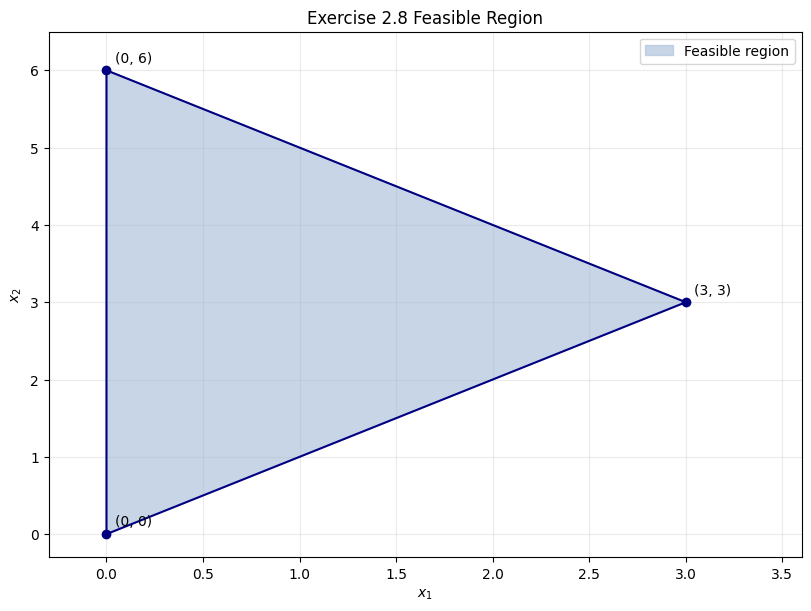

In [2]:
vertices_28 = np.array([[0.0, 0.0], [0.0, 6.0], [3.0, 3.0]])
closed_vertices_28 = np.vstack([vertices_28, vertices_28[0]])

figure, axis = plt.subplots(figsize=(8, 6), constrained_layout=True)
axis.fill(
    vertices_28[:, 0],
    vertices_28[:, 1],
    color="lightsteelblue",
    alpha=0.7,
    label="Feasible region",
)
axis.plot(closed_vertices_28[:, 0], closed_vertices_28[:, 1], color="navy")
axis.scatter(vertices_28[:, 0], vertices_28[:, 1], color="navy", zorder=3)
for x_value, y_value in vertices_28:
    axis.annotate(
        f"({x_value:.0f}, {y_value:.0f})",
        (x_value, y_value),
        xytext=(6, 6),
        textcoords="offset points",
    )
axis.set_xlim(-0.3, 3.6)
axis.set_ylim(-0.3, 6.5)
axis.set_xlabel("$x_1$")
axis.set_ylabel("$x_2$")
axis.set_title("Exercise 2.8 Feasible Region")
axis.legend()
axis.grid(alpha=0.25)
plt.show()

In [3]:
print("Feasible bases grouped by original-variable vertex:")
for vertex, bases in get_bases_by_vertex().items():
    print(f"  {vertex}: {bases}")

print("\nFull standard-form basic feasible solutions:")
for solution in get_basic_feasible_solutions():
    print(f"  basis={solution.basis}, values={solution.values}")

Feasible bases grouped by original-variable vertex:
  (3.0, 3.0): [('x1', 'x2', 's1'), ('x1', 'x2', 's2'), ('x1', 'x2', 's3')]
  (0.0, 0.0): [('x1', 's1', 's3'), ('x2', 's1', 's3'), ('s1', 's2', 's3')]
  (0.0, 6.0): [('x2', 's2', 's3')]

Full standard-form basic feasible solutions:
  basis=('x1', 'x2', 's1'), values=[3. 3. 0. 0. 0.]
  basis=('x1', 'x2', 's2'), values=[3. 3. 0. 0. 0.]
  basis=('x1', 'x2', 's3'), values=[3. 3. 0. 0. 0.]
  basis=('x1', 's1', 's3'), values=[0. 0. 6. 0. 3.]
  basis=('x2', 's1', 's3'), values=[0. 0. 6. 0. 3.]
  basis=('x2', 's2', 's3'), values=[0. 6. 0. 6. 3.]
  basis=('s1', 's2', 's3'), values=[0. 0. 6. 0. 3.]


Both $(0,0)$ and $(3,3)$ are degenerate extreme points: each has three different feasible bases. Thus basic feasible solutions and extreme points are not in one-to-one correspondence.

## Exercise 2.9

Each program is solved by generating every feasible nonsingular basis, calculating the objective $z=-x_1-2x_2$, and choosing the smallest value.

In [4]:
for label, result in (
    ("2.9(a)", solve_exercise_23a()),
    ("2.9(b)", solve_exercise_23b()),
):
    print(label)
    for solution in result.solutions:
        print(
            f"  basis={solution.basis}, values={np.round(solution.values, 6)}, z={solution.objective_value:.6f}"
        )
    print(f"  minimizing original variables={result.optimal_solution.values[:2]}\n")

2.9(a)
  basis=('x1', 'x2', 's1'), values=[2. 5. 1. 0. 0.], z=-12.000000
  basis=('x1', 'x2', 's3'), values=[1. 4. 0. 0. 1.], z=-9.000000
  basis=('x1', 's1', 's2'), values=[2. 0. 6. 5. 0.], z=-2.000000
  basis=('x2', 's2', 's3'), values=[0. 2. 0. 1. 2.], z=-4.000000
  basis=('s1', 's2', 's3'), values=[0. 0. 2. 3. 2.], z=0.000000
  minimizing original variables=[2. 5.]

2.9(b)
  basis=('x1', 'x2'), values=[3.333333 0.666667 0.       0.      ], z=-4.666667
  basis=('x1', 's1'), values=[4. 0. 2. 0.], z=-4.000000
  basis=('x1', 's2'), values=[2. 0. 0. 2.], z=-2.000000
  minimizing original variables=[3.33333333 0.66666667]



If $u$ and $v$ are optimal with objective value $z^*$, then $w=\lambda u+(1-\lambda)v$ is feasible and $c^Tw=\lambda z^*+(1-\lambda)z^*=z^*$, so the optimal set is convex. For the supplied data, each optimal set contains one point; every convex combination simply equals that point.

## Exercise 2.11

For any feasible $x$, move a sufficiently small distance in direction $c$: $y=x+\epsilon c$. Strict inequalities leave positive slack, so $\epsilon>0$ can be selected small enough that $Ay<b$. Since $c\ne0$, the objective improvement is $c^Ty-c^Tx=\epsilon c^Tc>0$. Every feasible point can be improved; therefore no optimum exists. The empty feasible-set case also has no optimal solution.

In [5]:
print(get_proof_summary())
direction = np.array([3.0, -4.0])
gain = objective_improvement(direction, step_size=0.25)
print(f"Illustration: c=(3, -4), epsilon=0.25, objective gain={gain:.2f}")

For any x with A @ x < b, choose epsilon > 0 small enough that y = x + epsilon*c still satisfies A @ y < b. Since c is nonzero, c @ y - c @ x = epsilon*(c @ c) > 0. Every feasible point can be strictly improved, so no optimum is attained.
Illustration: c=(3, -4), epsilon=0.25, objective gain=6.25


## Exercise 3.4

The feasible set is unbounded in the $x_1$ direction. Only a finite viewing window is plotted; the arrow indicates continuation to the right.

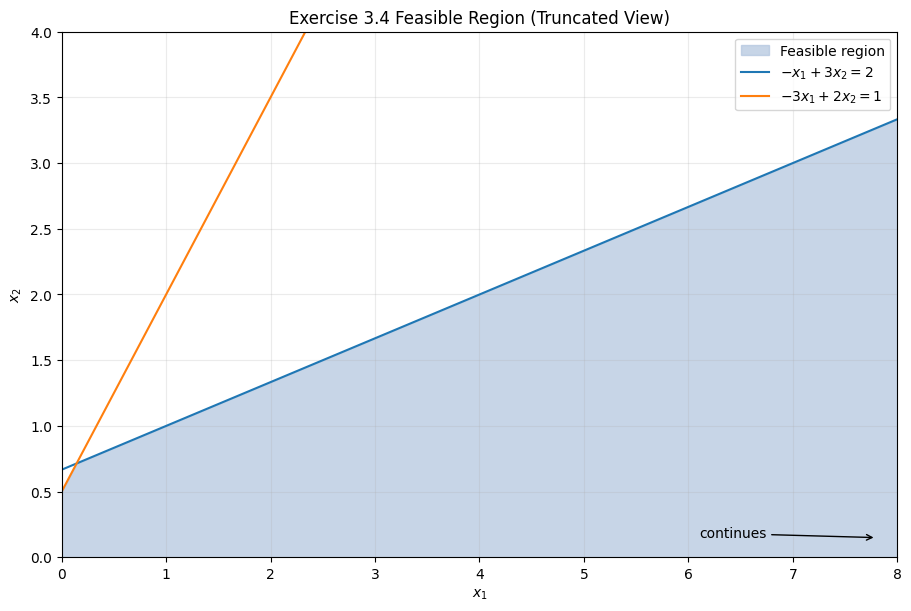

In [6]:
x1_grid = np.linspace(0.0, 8.0, 400)
first_upper_bound = (2.0 + x1_grid) / 3.0
second_upper_bound = (1.0 + 3.0 * x1_grid) / 2.0
feasible_upper_bound = np.minimum(first_upper_bound, second_upper_bound)

figure, axis = plt.subplots(figsize=(9, 6), constrained_layout=True)
axis.fill_between(
    x1_grid,
    0.0,
    feasible_upper_bound,
    color="lightsteelblue",
    alpha=0.7,
    label="Feasible region",
)
axis.plot(x1_grid, first_upper_bound, label="$-x_1+3x_2=2$")
axis.plot(x1_grid, second_upper_bound, label="$-3x_1+2x_2=1$")
axis.annotate(
    "continues", xy=(7.8, 0.15), xytext=(6.1, 0.15), arrowprops={"arrowstyle": "->"}
)
axis.set_xlim(0.0, 8.0)
axis.set_ylim(0.0, 4.0)
axis.set_xlabel("$x_1$")
axis.set_ylabel("$x_2$")
axis.set_title("Exercise 3.4 Feasible Region (Truncated View)")
axis.legend()
axis.grid(alpha=0.25)
plt.show()

In [7]:
result_34 = solve_exercise_34()
for iteration in result_34.iterations:
    basis = tuple(result_34.variable_names[index] for index in iteration.basis)
    print(
        f"iteration={iteration.iteration_number}, basis={basis}, x={np.round(iteration.solution, 6)}, z={iteration.objective_value:.6f}"
    )
print(
    f"status={result_34.status}, improving standard-form ray={result_34.unbounded_ray}"
)
print(
    f"objective slope along ray={result_34.objective_coefficients @ result_34.unbounded_ray:.6f}"
)

iteration=0, basis=('s1', 's2'), x=[0. 0. 2. 1.], z=0.000000
iteration=1, basis=('s1', 'x2'), x=[0.  0.5 0.5 0. ], z=-2.500000
iteration=2, basis=('x1', 'x2'), x=[0.142857 0.714286 0.       0.      ], z=-3.857143
status=unbounded, improving standard-form ray=[0.42857143 0.14285714 0.         1.        ]
objective slope along ray=-1.571429


The computed ray has objective slope $-11/7<0$, so the minimization objective decreases without bound. In the original coordinates, the simpler ray $(x_1,x_2)=(t,0)$ also proves unboundedness.

## Exercise 3.5

`exercise35.py` supplies the Python simplex calculation. It takes a standard-form objective vector, equality matrix, right-hand side, and initial basis.

In [8]:
solution_35 = solve_exercise_35()
result_35 = solution_35.simplex_result
for iteration in result_35.iterations:
    basis = tuple(result_35.variable_names[index] for index in iteration.basis)
    print(
        f"iteration={iteration.iteration_number}, basis={basis}, x={iteration.solution}, z={iteration.objective_value:.6f}"
    )
print(f"status={result_35.status}")
print("all optimal original-variable points: (x1, x2) = (t, 3), 0 <= t <= 6")
print(f"second endpoint={solution_35.second_optimal_point}")

iteration=0, basis=('s1', 's2', 's3'), x=[0. 0. 2. 3. 3.], z=0.000000
iteration=1, basis=('s1', 's2', 'x2'), x=[0. 3. 8. 6. 0.], z=-3.000000
status=optimal
all optimal original-variable points: (x1, x2) = (t, 3), 0 <= t <= 6
second endpoint=[6. 3.]
